In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
from portfolio import mean_variance_weights, equal_weight

returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)

print("Equal weight:")
print(equal_weight(returns).round(3))

# Sanity check: if every asset has the same expected return,
# the only thing left to optimize is risk
mu_flat = np.full(returns.shape[1], returns.mean().mean())
w_flat = mean_variance_weights(mu_flat, returns.cov().values)

print("\nMean-variance with identical expected returns:")
print(pd.Series(w_flat, index=returns.columns).round(3))

Equal weight:
SPY    0.1
EFA    0.1
EEM    0.1
TLT    0.1
IEF    0.1
LQD    0.1
HYG    0.1
GLD    0.1
VNQ    0.1
DBC    0.1
dtype: float64

Mean-variance with identical expected returns:
SPY    0.008
EFA    0.000
EEM    0.000
TLT    0.000
IEF    0.729
LQD    0.000
HYG    0.144
GLD    0.000
VNQ    0.000
DBC    0.119
dtype: float64


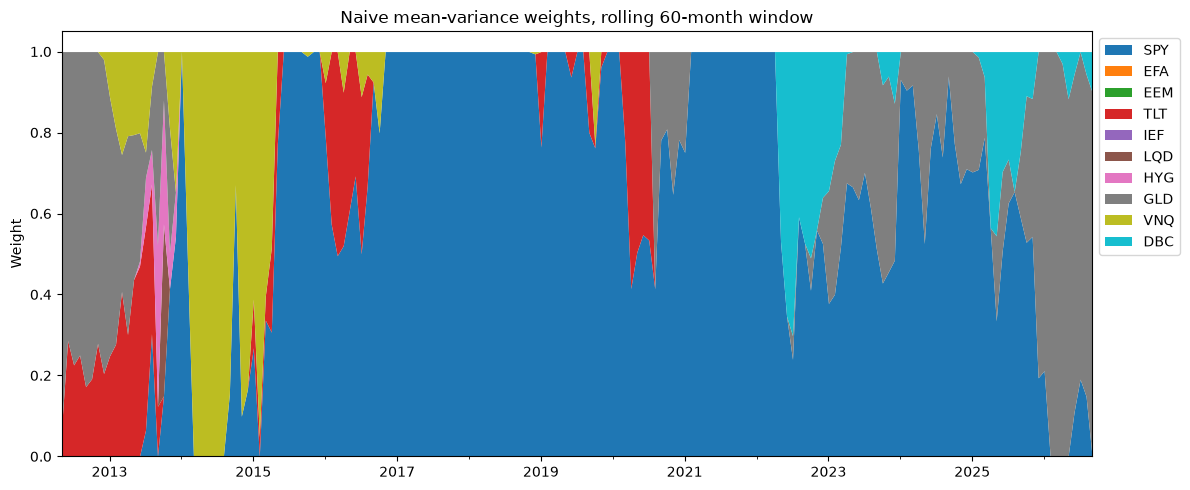

In [2]:
from portfolio import naive_mean_variance, ledoit_wolf_mean_variance
import matplotlib.pyplot as plt

WINDOW = 60  # months of history used for each estimate

def rolling_weights(strategy, returns, window=WINDOW):
    """Weights a strategy would hold each month, using only the previous `window` months."""
    records = {}
    for end in range(window, len(returns)):
        window_returns = returns.iloc[end - window:end]
        records[returns.index[end]] = strategy(window_returns)
    return pd.DataFrame(records).T

naive_w = rolling_weights(naive_mean_variance, returns)

naive_w.plot.area(figsize=(12, 5), linewidth=0,
                  title="Naive mean-variance weights, rolling 60-month window")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

                           naive  ledoit_wolf
avg effective # of assets   1.55         1.56
avg monthly turnover        0.25         0.25


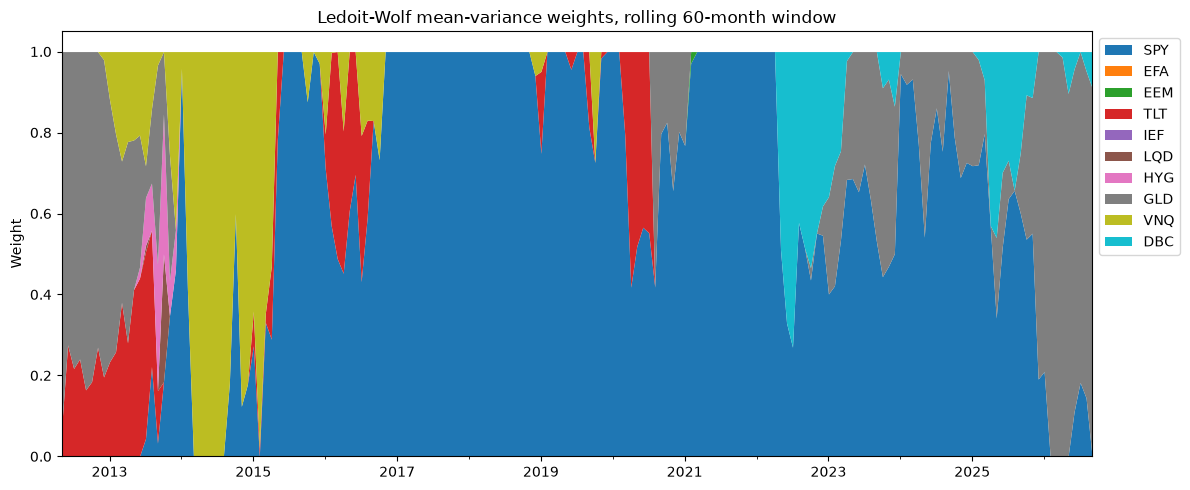

In [3]:
lw_w = rolling_weights(ledoit_wolf_mean_variance, returns)

def effective_n(weights):
    """Effective number of assets held: 1 / sum of squared weights."""
    return 1 / (weights ** 2).sum(axis=1)

def monthly_turnover(weights):
    """Sum of absolute weight changes each month (2.0 = complete portfolio swap)."""
    return weights.diff().abs().sum(axis=1)

comparison = pd.DataFrame({
    "naive": [effective_n(naive_w).mean(), monthly_turnover(naive_w).mean()],
    "ledoit_wolf": [effective_n(lw_w).mean(), monthly_turnover(lw_w).mean()],
}, index=["avg effective # of assets", "avg monthly turnover"])
print(comparison.round(2))

lw_w.plot.area(figsize=(12, 5), linewidth=0,
               title="Ledoit-Wolf mean-variance weights, rolling 60-month window")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [4]:
from sklearn.covariance import LedoitWolf

shrinkages = [
    LedoitWolf().fit(returns.iloc[end - WINDOW:end].values).shrinkage_
    for end in range(WINDOW, len(returns))
]

print(f"Average Ledoit-Wolf shrinkage intensity: {np.mean(shrinkages):.3f}")
print(f"Range: {np.min(shrinkages):.3f} to {np.max(shrinkages):.3f}")

Average Ledoit-Wolf shrinkage intensity: 0.124
Range: 0.071 to 0.190


In [5]:
import time
from portfolio import resampled_mean_variance

window = returns.iloc[-WINDOW:]  # the most recent 60 months

start = time.time()
w_resampled = resampled_mean_variance(window)
print(f"Time for one window: {time.time() - start:.1f} seconds")

pd.DataFrame({
    "naive": naive_mean_variance(window),
    "resampled": w_resampled,
}).round(3)

Time for one window: 0.6 seconds


,naive,resampled
SPY,0.138,0.228
EFA,0.000,0.017
EEM,0.000,0.020
TLT,0.000,0.000
IEF,0.000,0.000
LQD,0.000,0.000
HYG,0.000,0.002
GLD,0.787,0.521
VNQ,0.000,0.000
DBC,0.075,0.211


In [6]:
w_500 = resampled_mean_variance(window, n_draws=500)
print(f"Largest weight difference, 200 vs 500 draws: {(w_resampled - w_500).abs().max():.3f}")

Largest weight difference, 200 vs 500 draws: 0.033


                           naive  ledoit_wolf  resampled
avg effective # of assets   1.55         1.56       2.84
avg monthly turnover        0.25         0.25       0.16


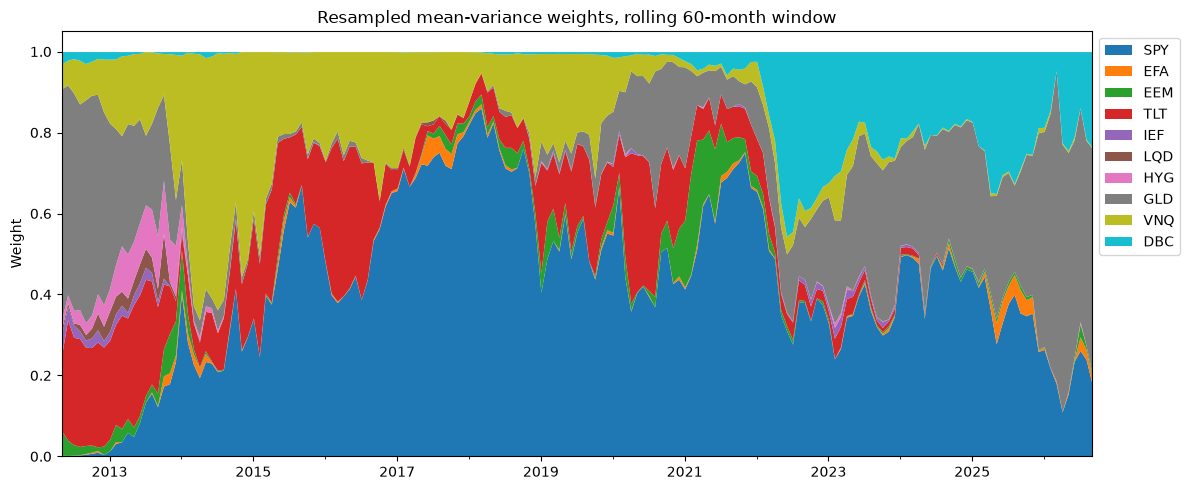

In [7]:
resampled_w = rolling_weights(resampled_mean_variance, returns)

comparison["resampled"] = [effective_n(resampled_w).mean(), monthly_turnover(resampled_w).mean()]
print(comparison.round(2))

resampled_w.plot.area(figsize=(12, 5), linewidth=0,
                      title="Resampled mean-variance weights, rolling 60-month window")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [3]:
from portfolio import black_litterman_no_views, implied_returns, MARKET_WEIGHTS
from pypfopt.black_litterman import market_implied_prior_returns
from sklearn.covariance import LedoitWolf

window = returns.iloc[-WINDOW:]
sigma_lw = pd.DataFrame(LedoitWolf().fit(window.values).covariance_,
                        index=window.columns, columns=window.columns)
w_mkt = MARKET_WEIGHTS[window.columns]

ours = pd.Series(implied_returns(sigma_lw, w_mkt), index=window.columns)
theirs = market_implied_prior_returns(w_mkt, 2.5, sigma_lw, risk_free_rate=0.0)

pd.DataFrame({
    "implied_ann_ours": ours * 12,
    "implied_ann_pypfopt": theirs * 12,
    "bl_no_views_weight": black_litterman_no_views(window),
    "market_weight": w_mkt,
}).round(3)

,implied_ann_ours,implied_ann_pypfopt,bl_no_views_weight,market_weight
SPY,0.036,0.036,0.25,0.25
EFA,0.037,0.037,0.15,0.15
EEM,0.037,0.037,0.07,0.07
TLT,0.029,0.029,0.08,0.08
IEF,0.016,0.016,0.12,0.12
LQD,0.023,0.023,0.12,0.12
HYG,0.017,0.017,0.05,0.05
GLD,0.020,0.020,0.06,0.06
VNQ,0.042,0.042,0.05,0.05
DBC,0.006,0.006,0.05,0.05


In [3]:
from portfolio import (momentum_view, black_litterman_returns, black_litterman_momentum,
                       implied_returns, MARKET_WEIGHTS)
from pypfopt.black_litterman import BlackLittermanModel
from sklearn.covariance import LedoitWolf

window = returns.iloc[-WINDOW:]
sigma_lw = pd.DataFrame(LedoitWolf().fit(window.values).covariance_,
                        index=window.columns, columns=window.columns)
w_mkt = MARKET_WEIGHTS[window.columns]
prior = pd.Series(implied_returns(sigma_lw, w_mkt), index=window.columns)

P, Q, top, bottom = momentum_view(window)
print(f"View: {top} outperform {bottom} by {Q[0] * 12:.1%} per year\n")

ours_post = pd.Series(black_litterman_returns(sigma_lw, w_mkt, P=P, Q=Q), index=window.columns)
theirs_post = BlackLittermanModel(sigma_lw, pi=prior, P=P.reshape(1, -1), Q=Q, tau=0.05).bl_returns()

pd.DataFrame({
    "prior_ann": prior * 12,
    "posterior_ann_ours": ours_post * 12,
    "posterior_ann_pypfopt": theirs_post * 12,
    "bl_momentum_weight": black_litterman_momentum(window),
    "market_weight": w_mkt,
}).round(3)

View: ['SPY', 'EEM', 'DBC'] outperform ['TLT', 'LQD', 'IEF'] by 3.0% per year



,prior_ann,posterior_ann_ours,posterior_ann_pypfopt,bl_momentum_weight,market_weight
SPY,0.036,0.041,0.041,0.388,0.25
EFA,0.037,0.039,0.039,0.151,0.15
EEM,0.037,0.042,0.042,0.187,0.07
TLT,0.029,0.022,0.022,0.000,0.08
IEF,0.016,0.011,0.011,0.000,0.12
LQD,0.023,0.020,0.020,0.000,0.12
HYG,0.017,0.018,0.018,0.000,0.05
GLD,0.020,0.020,0.020,0.048,0.06
VNQ,0.042,0.043,0.043,0.031,0.05
DBC,0.006,0.020,0.020,0.194,0.05
